# Sistema de Recomendación de Películas Basado en Contenido

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** IA & Big Data · Sistemas de Recomendación · Content-Based Filtering (TF-IDF + Similitud Coseno)

---

## Objetivo

Construir un recomendador de películas **basado en contenido** (*content-based filtering*): a partir del género y la sinopsis de cada película, vectorizamos el texto con **TF-IDF** y calculamos la **similitud coseno** entre todas las películas del catálogo para, dado un título, sugerir los más parecidos — sin usar valoraciones ni historial de otros usuarios.

## Contexto de negocio

**El cliente:** una plataforma de streaming (estilo Netflix) que quiere ofrecer recomendaciones de catálogo a sus usuarios.

**El problema:** las películas recién incorporadas al catálogo todavía no tienen historial de visualizaciones ni valoraciones — un sistema de filtrado colaborativo (basado en "a usuarios parecidos a ti les gustó...") no tiene datos con los que trabajar todavía (*cold start*). Sin embargo, sí se conocen sus metadatos (género, sinopsis) desde el momento en que se suben.

**La pregunta:** dado que a un usuario le ha gustado una película concreta, ¿qué otras películas del catálogo son más parecidas en contenido (género + argumento) y merece la pena recomendarle?

## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# Estilo visual -- sistema de color validado (consejo UX/UI Data)
BACKGROUND    = "#fbfbfb"
PURPLE        = "#7a7bff"
PURPLE_LIGHT  = "#9b9cff"
POSITIVE      = "#6b8158"
NEGATIVE      = "#c34031"
NEUTRAL_BAR   = "#d9d9d9"
NEUTRAL_LINE  = "#8f8c9e"
CONTEXT_LINES = [NEUTRAL_LINE, "#a89a8a", "#7d94a8"]
INK           = "#111111"
MUTED         = "#707070"

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 100,
    "figure.facecolor": BACKGROUND,
    "axes.facecolor": BACKGROUND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlecolor": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.family": "sans-serif",
    "font.size": 10,
    "grid.color": "#f0f0f0",
    "grid.linewidth": 0.5,
})

## 2. Carga y exploración de datos

El catálogo son 50 películas reales con cuatro campos: `id`, `titulo`, `genero` (un único género por película) y `descripcion` (sinopsis breve).

In [2]:
df = pd.read_excel("peliculas_netflix.xlsx")
print(f"Películas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head(10)

Películas: 50 | Columnas: 4


,id,titulo,genero,descripcion
0,1,El Padrino,Crimen,El patriarca de una familia de la mafia italoa...
1,2,Pulp Fiction,Crimen,"Las vidas de dos sicarios, un boxeador y la es..."
2,3,El Caballero Oscuro,Acción,"Batman se enfrenta al Joker, un criminal anarq..."
3,4,Origen,Ciencia Ficción,Un ladrón especializado en robar secretos del ...
4,5,Matrix,Ciencia Ficción,Un programador descubre que la realidad que co...
5,6,Forrest Gump,Drama,Un hombre de buen corazón e intelecto limitado...
6,7,Titanic,Romance,Un artista sin recursos y una joven de la alta...
7,8,Parásitos,Drama,Una familia humilde se infiltra poco a poco en...
8,9,Interstellar,Ciencia Ficción,Un grupo de astronautas viaja a través de un a...
9,10,Gladiador,Acción,Un general romano traicionado es reducido a es...


In [3]:
df["genero"].value_counts()

genero
Drama              7
Terror             6
Animación          6
Acción             5
Suspense           5
Romance            4
Ciencia Ficción    4
Crimen             3
Fantasía           2
Comedia            2
Aventura           1
Misterio           1
Deporte            1
Biografía          1
Western            1
Bélica             1
Name: count, dtype: int64

**Interpretación del catálogo:** el dataset tiene **50 películas** repartidas en **16 géneros**, con `Drama` (7), `Terror` (6) y `Animación` (6) como los más representados. Es un catálogo pequeño y deliberadamente heterogéneo: sirve para validar que el recomendador funciona, no para sacar conclusiones estadísticas robustas sobre géneros.

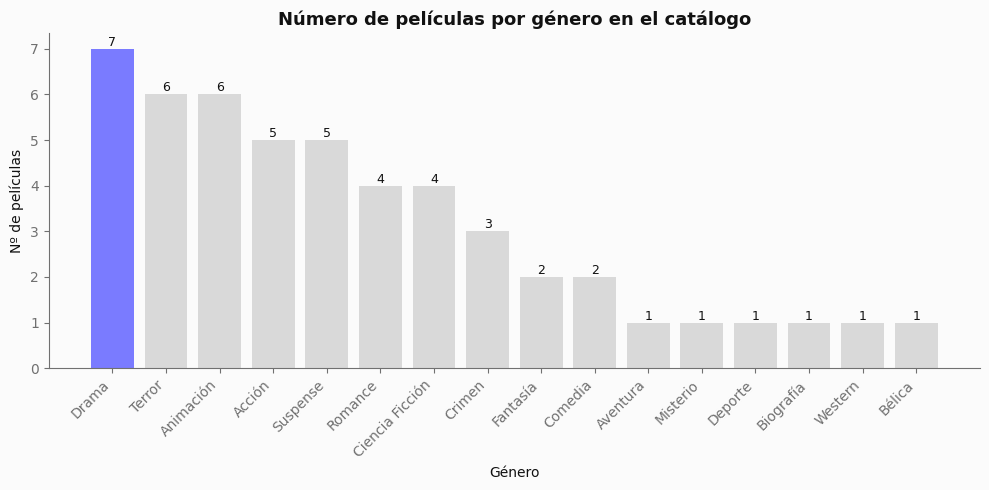

In [4]:
conteo_generos = df["genero"].value_counts()
colores_genero = [PURPLE if v == conteo_generos.max() else NEUTRAL_BAR for v in conteo_generos.values]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(conteo_generos.index, conteo_generos.values, color=colores_genero)

for bar, valor in zip(bars, conteo_generos.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(valor),
            ha="center", va="bottom", fontsize=9, color=INK)

ax.set_title("Número de películas por género en el catálogo")
ax.set_xlabel("Género")
ax.set_ylabel("Nº de películas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 3. Preparación del contenido: combinar género y descripción

El objetivo original solo vectorizaba la `descripcion`. El `genero` es información de contenido tan válida como la sinopsis para decidir si dos películas se parecen, así que lo incorporamos: creamos una columna `contenido` que concatena `genero` + `descripcion` y es la que se vectoriza a continuación. Así, dos películas del mismo género comparten al menos un término fuerte en su vector, además de cualquier parecido léxico en el argumento.

In [5]:
df["contenido"] = df["genero"] + ". " + df["descripcion"]
df[["titulo", "genero", "contenido"]].head()

,titulo,genero,contenido
0,El Padrino,Crimen,Crimen. El patriarca de una familia de la mafi...
1,Pulp Fiction,Crimen,"Crimen. Las vidas de dos sicarios, un boxeador..."
2,El Caballero Oscuro,Acción,"Acción. Batman se enfrenta al Joker, un crimin..."
3,Origen,Ciencia Ficción,Ciencia Ficción. Un ladrón especializado en ro...
4,Matrix,Ciencia Ficción,Ciencia Ficción. Un programador descubre que l...


## 4. Vectorización TF-IDF

`TfidfVectorizer` convierte cada texto en un vector numérico donde cada palabra pesa según:
- **Term Frequency (TF):** cuántas veces aparece la palabra en ese texto.
- **Inverse Document Frequency (IDF):** cuánto de rara es esa palabra en el conjunto de todas las películas (palabras muy comunes — "un", "una", "de", "la"... — pesan poco).

Para que el idioma no distorsione el resultado, filtramos primero las **stopwords en español** (artículos, preposiciones, pronombres): sklearn solo trae una lista de stopwords en inglés, así que definimos una propia.

In [6]:
STOPWORDS_ES = [
    "de", "la", "que", "el", "en", "y", "a", "los", "del", "se", "las", "por", "un",
    "para", "con", "no", "una", "su", "al", "lo", "como", "mas", "pero", "sus", "le",
    "ya", "o", "este", "si", "porque", "esta", "entre", "cuando", "muy", "sin", "sobre",
    "tambien", "me", "hasta", "hay", "donde", "quien", "desde", "todo", "nos", "durante",
    "todos", "uno", "les", "ni", "contra", "otros", "ese", "eso", "ante", "ellos", "e",
    "esto", "mi", "antes", "algunos", "unos", "yo", "otro", "otras", "otra", "tanto",
    "esa", "estos", "mucho", "quienes", "nada", "muchos", "cual", "poco", "ella",
    "estar", "estas", "algunas", "algo", "nosotros", "mis", "tu", "te", "ti", "tus",
    "ellas", "nosotras", "vosotros", "vosotras", "os", "es", "son", "fue", "ser", "han", "ha",
]

vectorizer = TfidfVectorizer(stop_words=STOPWORDS_ES)
matriz_tfidf = vectorizer.fit_transform(df["contenido"])

print(f"Matriz TF-IDF: {matriz_tfidf.shape[0]} películas x {matriz_tfidf.shape[1]} términos del vocabulario")

Matriz TF-IDF: 50 películas x 505 términos del vocabulario


**Interpretación:** cada una de las 50 películas queda representada como un vector de varios cientos de dimensiones (una por cada palabra distinta del vocabulario, tras quitar stopwords). La inmensa mayoría de posiciones de cada vector son cero — cada sinopsis solo usa un puñado de esas palabras —, lo cual es normal en TF-IDF y es precisamente el reto que resolvemos más abajo al reducir a 2D.

## 5. Matriz de similitud coseno

Con los vectores TF-IDF calculamos la **similitud coseno** entre cada par de películas: un valor entre 0 (nada parecidas) y 1 (idénticas en su vector de contenido). La diagonal vale siempre 1, porque cada película es idéntica a sí misma.

In [7]:
matriz_similitud = cosine_similarity(matriz_tfidf)

df_similitud = pd.DataFrame(
    matriz_similitud,
    index=df["titulo"],
    columns=df["titulo"],
)

df_similitud.round(2).iloc[:8, :8]

titulo,El Padrino,Pulp Fiction,El Caballero Oscuro,Origen,Matrix,Forrest Gump,Titanic,Parásitos
titulo,,,,,,,,
El Padrino,1.00,0.06,0.06,0.00,0.00,0.00,0.0,0.08
Pulp Fiction,0.06,1.00,0.00,0.00,0.00,0.00,0.0,0.00
El Caballero Oscuro,0.06,0.00,1.00,0.00,0.00,0.00,0.0,0.00
Origen,0.00,0.00,0.00,1.00,0.09,0.00,0.0,0.00
Matrix,0.00,0.00,0.00,0.09,1.00,0.00,0.0,0.00
Forrest Gump,0.00,0.00,0.00,0.00,0.00,1.00,0.0,0.04
Titanic,0.00,0.00,0.00,0.00,0.00,0.00,1.0,0.00
Parásitos,0.08,0.00,0.00,0.00,0.00,0.04,0.0,1.00


## 6. Motor de recomendación

La primera versión de este notebook consultaba `df_similitud[pelicula]` y se quedaba con las primeras filas — pero la fila con mayor similitud es siempre **la propia película** (similitud = 1 consigo misma), así que la "recomendación número 1" nunca era una recomendación real. Lo encapsulamos en una función que excluye la película de partida y valida que el título exista en el catálogo.

In [8]:
def recomendar(titulo, n=5, df_similitud=df_similitud):
    """Devuelve las n películas más similares a `titulo`, excluyéndola a ella misma."""
    if titulo not in df_similitud.columns:
        raise ValueError(f"'{titulo}' no está en el catálogo.")

    similitudes = df_similitud[titulo].sort_values(ascending=False)
    similitudes = similitudes.drop(titulo)
    return similitudes.head(n)

In [9]:
recomendar("Up", n=5)

titulo
Shrek              0.108772
Get Out            0.067211
Coco               0.040971
Los Increíbles     0.039453
Buscando a Nemo    0.038711
Name: Up, dtype: float64

In [10]:
recomendar("El Padrino", n=5)

titulo
El Irlandés     0.182665
Parásitos       0.077244
Joker           0.064791
Enola Holmes    0.062025
Pulp Fiction    0.061646
Name: El Padrino, dtype: float64

**Interpretación:** para **El Padrino** el recomendador acierta claramente — sus 5 vecinos más cercanos son casi todo cine de mafia/crimen (`El Irlandés`, `Parásitos`, `Joker`, `Pulp Fiction`). Para **Up** el resultado es más mixto: sus 5 vecinos son casi todo animación (`Shrek`, `Coco`, `Los Increíbles`, `Buscando a Nemo`), pero en segunda posición se cuela `Get Out`, una película de terror sin relación temática real. Esto no es un bug: TF-IDF mide **solapamiento de palabras**, no significado. Si dos sinopsis comparten términos genéricos (p. ej. "familia"), el modelo las acerca aunque hablen de historias completamente distintas. Es una limitación real y conocida de TF-IDF que retomamos en la sección 8.

## 7. Visualización: mapa de películas en 2D (PCA sobre TF-IDF)

Cada película vive en un espacio de varios cientos de dimensiones (una por término del vocabulario). No podemos verlo directamente, pero podemos proyectarlo a 2 dimensiones con **PCA** (Análisis de Componentes Principales) para explorar visualmente si las películas se agrupan por género.

In [11]:
pca = PCA(n_components=2, random_state=42)
coordenadas = pca.fit_transform(matriz_tfidf.toarray())

df_pca = df.copy()
df_pca["pca_1"] = coordenadas[:, 0]
df_pca["pca_2"] = coordenadas[:, 1]

varianza_explicada = pca.explained_variance_ratio_
print(f"Varianza explicada: PC1 = {varianza_explicada[0]:.1%} | PC2 = {varianza_explicada[1]:.1%} | Total = {varianza_explicada.sum():.1%}")

Varianza explicada: PC1 = 3.1% | PC2 = 2.9% | Total = 5.9%


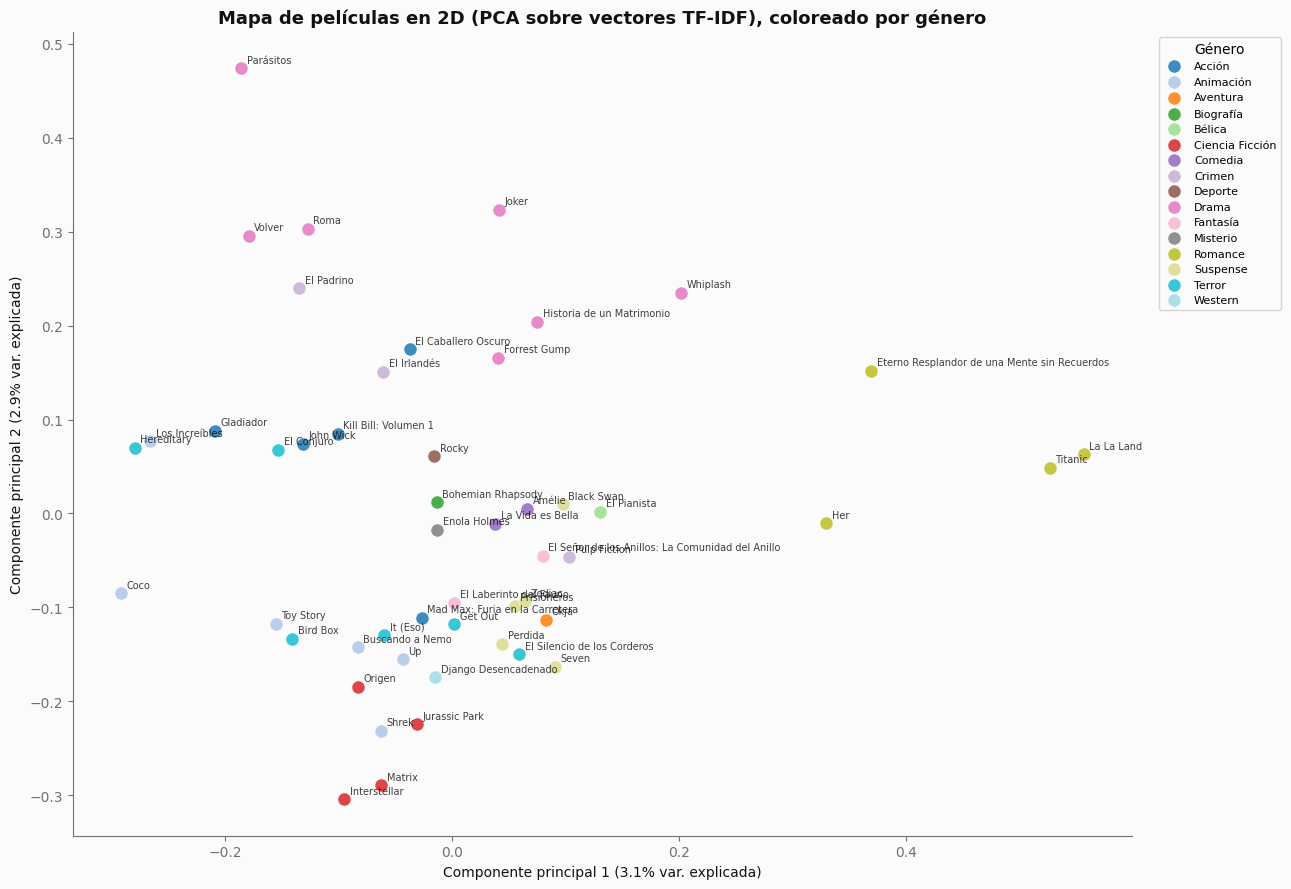

In [12]:
generos = sorted(df_pca["genero"].unique())
colores = plt.cm.tab20(np.linspace(0, 1, len(generos)))

plt.figure(figsize=(13, 9))
for genero, color in zip(generos, colores):
    subset = df_pca[df_pca["genero"] == genero]
    plt.scatter(subset["pca_1"], subset["pca_2"], label=genero, color=color, s=90, alpha=0.85, edgecolors="white", linewidths=0.5)

for _, fila in df_pca.iterrows():
    plt.annotate(fila["titulo"], (fila["pca_1"], fila["pca_2"]), fontsize=7, alpha=0.75, xytext=(4, 4), textcoords="offset points")

plt.title("Mapa de películas en 2D (PCA sobre vectores TF-IDF), coloreado por género")
plt.xlabel(f"Componente principal 1 ({varianza_explicada[0]:.1%} var. explicada)")
plt.ylabel(f"Componente principal 2 ({varianza_explicada[1]:.1%} var. explicada)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title="Género")
plt.tight_layout()
plt.show()

**Interpretación de la reducción dimensional:** las dos componentes principales explican en conjunto muy poca varianza del total (en torno al **6%**). Es un resultado esperado y hay que leerlo con honestidad: TF-IDF genera un espacio disperso de varios cientos de dimensiones (una por palabra del vocabulario), y PCA es una técnica **lineal** — comprimir eso a 2 ejes necesariamente pierde casi toda la información. El mapa es útil como exploración visual rápida (algunos géneros con vocabulario muy distintivo, como `Animación` o `Terror`, sí tienden a agruparse), pero no hay que interpretar la cercanía en el gráfico como una medida fiable de similitud — para eso está la matriz de similitud coseno de la sección 5, que trabaja sobre el espacio completo. Una alternativa no lineal como *t-SNE* suele separar mejor los grupos visualmente, a costa de que los ejes dejen de tener una interpretación directa (varianza explicada); queda como posible mejora futura.

## 8. Cómo lo hacen las empresas reales

Este notebook usa una versión simplificada, a pequeña escala y totalmente explicable, de una técnica que sí se usa en producción. Cómo la usan compañías reales:

| Empresa | Qué hacen (con contenido) | Por qué |
|---|---|---|
| **Netflix** | Combinan señales de contenido (metadatos, sinopsis, imágenes de las miniaturas) con modelos de secuencia sobre el historial de visionado; su función "Porque viste..." es filtrado basado en contenido en estado puro. En 2025 están incorporando *foundation models*/LLMs que tratan el historial de cada usuario como una secuencia de texto. | Más del 80% de lo que se consume en la plataforma se descubre vía recomendación personalizada — el motor no es un extra, es el producto. |
| **Spotify** | "Artistas similares" y buena parte de las playlists de descubrimiento combinan metadatos y letras (texto, como aquí) con *embeddings* de audio y señales de comportamiento colectivo. | El contenido (letra, género, audio) permite recomendar canciones nuevas que aún no tienen apenas reproducciones — el mismo problema de *cold start* que motiva este notebook. |
| **Amazon** | Históricamente pionero en filtrado colaborativo ítem-a-ítem ("quien compró esto también compró..."), combinado hoy con señales de contenido (categoría, descripción, atributos del producto). | El filtrado colaborativo solo funciona con histórico de compras; el contenido cubre productos nuevos sin ese histórico. |

**El patrón común — sistemas híbridos:** casi ningún recomendador de producción usa *solo* contenido o *solo* filtrado colaborativo. Se combinan para compensar las debilidades de cada uno: el contenido resuelve el arranque en frío (ítems nuevos sin historial, exactamente nuestro caso de negocio), mientras que el filtrado colaborativo capta gustos que el texto no puede describir (el "no sé explicar por qué, pero me gusta").

**De TF-IDF a *embeddings*:** el límite que vimos en la sección 6 (`Up` recomendando `Get Out` por compartir la palabra "familia") es justo la razón por la que la industria ha ido sustituyendo TF-IDF por *embeddings* semánticos (Word2Vec, BERT, modelos tipo GPT): en lugar de contar palabras exactas, representan el **significado** del texto, así que dos sinopsis pueden parecerse aunque no compartan ni una palabra literal. TF-IDF sigue siendo un punto de partida legítimo — es ligero, instantáneo de calcular y totalmente interpretable (se puede explicar palabra a palabra por qué dos películas se parecen) — pero a mayor escala y con más matices de significado, los embeddings ganan.

## Conclusión

> **El hallazgo:** con solo género + sinopsis (sin una sola valoración de usuario) el modelo ya distingue géneros de forma razonable — funciona especialmente bien cuando el vocabulario del género es distintivo (crimen, terror), y peor cuando las sinopsis comparten palabras genéricas entre géneros distintos. Es la prueba de concepto de por qué el contenido es la pieza que resuelve el arranque en frío en un catálogo real.

**Recomendaciones para llevar esto a producción:**
1. **Combinarlo con filtrado colaborativo** en cuanto haya historial de visualizaciones/valoraciones, siguiendo el patrón híbrido de la sección 8 — el contenido cubre el catálogo nuevo, el colaborativo capta gustos que el texto no explica.
2. **Sustituir TF-IDF por *embeddings* semánticos** (p. ej. `sentence-transformers`) si el catálogo crece y las sinopsis empiezan a compartir vocabulario genérico entre géneros distintos — resolvería directamente el caso `Up` → `Get Out` visto en la sección 6.
3. **Enriquecer el contenido** con más metadatos disponibles desde el alta del ítem (director, reparto, año, duración, palabras clave) para dar más señal al vector sin depender de historial de usuario.
4. **Medir con datos reales de interacción** (clicks, tiempo visto, valoraciones) en cuanto existan — la similitud coseno es una proxy razonable del parecido de contenido, pero la única validación que importa en negocio es si el usuario acaba viendo lo recomendado.